# BTC Volatility Transformer - Part 1: Data Pipeline

**Project Goal**: Build a transformer model to predict Bitcoin volatility, then use it as part of a trading agent (Week 4 MCP capstone).

**This Notebook**: Fetch hourly BTC data, engineer features, and prepare for both:
1. **Model training** (volatility prediction)
2. **Trading evaluation** (backtesting with realistic costs)

---

## Learning Objectives

By the end of this notebook, you'll understand:
- How to securely use API keys in Colab
- The difference between Alpaca's stock and crypto APIs
- Feature engineering for volatility prediction
- Why and how we estimate bid-ask spreads
- Chronological data splitting for time series
- Data structures that support both prediction AND trading evaluation

---
## Section 1: Setup and API Keys

### 🎓 Teaching Moment: Secure API Key Management

**Never hardcode API keys in notebooks!** If you share the notebook or push to GitHub, your keys are exposed.

Colab provides a **Secrets** feature (the 🔑 icon in the left panel) that stores keys securely. Here's how:

1. Click the 🔑 icon in Colab's left sidebar
2. Add two secrets:
   - Name: `ALPACA_API_KEY` → Value: your API key
   - Name: `ALPACA_SECRET_KEY` → Value: your secret key
3. Toggle "Notebook access" ON for each

The `userdata.get()` function retrieves these at runtime without exposing them in code.

In [1]:
# =============================================================================
# STEP 1.1: Install required packages
# =============================================================================
# alpaca-py is Alpaca's official Python SDK (released 2023, replaces alpaca-trade-api)
# tqdm gives us progress bars for long downloads

!pip install alpaca-py tqdm --quiet
print("✓ Packages installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 5.7 MB/s eta 0:00:00
✓ Packages installed


In [2]:
# =============================================================================
# STEP 1.2: Import libraries
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Alpaca imports
from alpaca.data.historical import CryptoHistoricalDataClient
from alpaca.data.requests import CryptoBarsRequest
from alpaca.data.timeframe import TimeFrame

print("✓ Libraries imported")

✓ Libraries imported


In [3]:
# =============================================================================
# STEP 1.3: Load API keys from Colab Secrets
# =============================================================================

from google.colab import userdata

try:
    ALPACA_API_KEY = userdata.get('ALPACA_API_KEY')
    ALPACA_SECRET_KEY = userdata.get('ALPACA_SECRET_KEY')
    print("✓ API keys loaded from Colab Secrets")
    print(f"  Key preview: {ALPACA_API_KEY[:8]}...{ALPACA_API_KEY[-4:]}")
except Exception as e:
    print("⚠️  Could not load API keys from Colab Secrets.")
    print("   Please add ALPACA_API_KEY and ALPACA_SECRET_KEY via the 🔑 icon.")
    print(f"   Error: {e}")
    print("\n   Falling back to unauthenticated mode (slower rate limits)...")
    ALPACA_API_KEY = None
    ALPACA_SECRET_KEY = None

✓ API keys loaded from Colab Secrets
  Key preview: PK1VIVB1...ITUK


In [4]:
# =============================================================================
# STEP 1.4: Initialize the Crypto Data Client
# =============================================================================

# 🎓 Teaching Moment: Stock vs Crypto Clients
#
# Alpaca provides separate clients for different asset classes:
#   - StockHistoricalDataClient  → requires API keys
#   - CryptoHistoricalDataClient → works without keys (but keys = faster)
#   - OptionHistoricalDataClient → requires keys
#
# Your SPY notebook used StockHistoricalDataClient.
# For BTC, we use CryptoHistoricalDataClient.

if ALPACA_API_KEY and ALPACA_SECRET_KEY:
    client = CryptoHistoricalDataClient(
        api_key=ALPACA_API_KEY,
        secret_key=ALPACA_SECRET_KEY
    )
    print("✓ Crypto client initialized WITH authentication (faster rate limits)")
else:
    client = CryptoHistoricalDataClient()
    print("✓ Crypto client initialized WITHOUT authentication (slower rate limits)")

✓ Crypto client initialized WITH authentication (faster rate limits)


---
## Section 2: Fetch Hourly BTC Data

### 🎓 Teaching Moment: Why Hourly Data?

| Timeframe | Data Points (more than 5 years years) | Pros | Cons |
|-----------|------------------------|------|------|
| Daily | ~1,900 | Simple, less noise | Too few for deep learning |
| Hourly | ~46,000 | Good balance | Some noise |
| Minute | ~2.8 million | Lots of data | Very noisy, storage heavy |

Your SPY model had ~1,245 daily observations and struggled to beat EWMA.
With ~46,000 hourly BTC observations, you can train a larger model without overfitting.

### 🎓 Teaching Moment: Symbol Format

- Stocks: `"SPY"`, `"AAPL"`
- Crypto: `"BTC/USD"`, `"ETH/USD"` (note the slash!)

The slash indicates a trading pair: BTC priced in USD.

In [9]:
# =============================================================================
# STEP 2.1: Define date range
# =============================================================================

# Alpaca crypto data starts around January 1, 2021
START_DATE = datetime(2021, 1, 1)
END_DATE = datetime(2026, 3, 29)  # Adjust to today's date if needed

# Calculate expected data points
days = (END_DATE - START_DATE).days
expected_hours = days * 24

print(f"Date range: {START_DATE.date()} to {END_DATE.date()}")
print(f"Days: {days:,}")
print(f"Expected hourly bars: ~{expected_hours:,}")

Date range: 2021-01-01 to 2026-03-29
Days: 1,913
Expected hourly bars: ~45,912


In [10]:
# =============================================================================
# STEP 2.2: Fetch the data
# =============================================================================

# 🎓 Teaching Moment: The SDK handles pagination automatically!
#
# The Alpaca API returns max 10,000 bars per request.
# For 55,500 bars, that would require 6 manual requests.
# But alpaca-py handles this internally - you just make one call.

print(f"Fetching BTC/USD hourly bars...")
print(f"This may take 1-3 minutes for {expected_hours:,} bars.\n")

request_params = CryptoBarsRequest(
    symbol_or_symbols="BTC/USD",
    timeframe=TimeFrame.Hour,
    start=START_DATE,
    end=END_DATE
)

# This single call fetches ALL the data (with internal pagination)
bars = client.get_crypto_bars(request_params)

# Convert to DataFrame
df_raw = bars.df

print(f"✓ Fetched {len(df_raw):,} hourly bars!")

Fetching BTC/USD hourly bars...
This may take 1-3 minutes for 45,912 bars.

✓ Fetched 45,893 hourly bars!


In [11]:
# =============================================================================
# STEP 2.3: Examine the raw data structure
# =============================================================================

# 🎓 Teaching Moment: MultiIndex DataFrames
#
# Alpaca returns a MultiIndex DataFrame with (symbol, timestamp) as the index.
# This is useful when fetching multiple symbols at once.
# For single-symbol requests, we'll flatten it.

print("Raw DataFrame structure:")
print(f"Index type: {type(df_raw.index)}")
print(f"Index names: {df_raw.index.names}")
print(f"\nColumns: {df_raw.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df_raw.tail(3))

Raw DataFrame structure:
Index type: <class 'pandas.core.indexes.multi.MultiIndex'>
Index names: ['symbol', 'timestamp']

Columns: ['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap']

First 3 rows:
                                        open          high        low  \
symbol  timestamp                                                       
BTC/USD 2026-03-28 22:00:00+00:00  66630.420  66897.041185  66541.460   
        2026-03-28 23:00:00+00:00  66699.800  66699.800000  66223.442   
        2026-03-29 00:00:00+00:00  66314.195  66488.350000  66221.660   

                                        close    volume  trade_count  \
symbol  timestamp                                                      
BTC/USD 2026-03-28 22:00:00+00:00  66709.6120  0.183405         75.0   
        2026-03-28 23:00:00+00:00  66310.4750  0.039272         65.0   
        2026-03-29 00:00:00+00:00  66425.3175  0.027300         52.0   

                                           vwap  
symbol  tim

In [12]:
# =============================================================================
# STEP 2.4: Clean and flatten the DataFrame
# =============================================================================

df = df_raw.reset_index()  # Flatten the MultiIndex

# Drop the symbol column (we only have BTC/USD)
df = df.drop(columns=['symbol'])

# Rename for clarity
df = df.rename(columns={'timestamp': 'datetime'})

# Ensure sorted by time
df = df.sort_values('datetime').reset_index(drop=True)

# Convert datetime to timezone-naive for easier handling
df['datetime'] = pd.to_datetime(df['datetime']).dt.tz_localize(None)

print(f"Cleaned DataFrame shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDate range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"\nFirst 5 rows:")
print(df.head())

Cleaned DataFrame shape: (45893, 8)

Columns: ['datetime', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap']

Date range: 2021-01-01 06:00:00 to 2026-03-29 00:00:00

First 5 rows:
             datetime      open      high       low     close     volume  \
0 2021-01-01 06:00:00  29255.71  29338.25  29153.55  29234.15  42.244289   
1 2021-01-01 07:00:00  29235.61  29236.95  28905.00  29162.50  34.506038   
2 2021-01-01 08:00:00  29162.50  29248.52  28948.86  29076.77  27.596804   
3 2021-01-01 09:00:00  29075.31  29372.32  29058.05  29284.92  20.694200   
4 2021-01-01 10:00:00  29291.54  29400.00  29232.16  29286.63  16.617646   

   trade_count          vwap  
0       1243.0  29237.240312  
1       1070.0  29078.423185  
2       1110.0  29091.465155  
3        880.0  29248.730924  
4        742.0  29338.609132  


In [13]:
# =============================================================================
# STEP 2.5: Understand each column
# =============================================================================

# 🎓 Teaching Moment: OHLCV Bar Data
#
# Each bar summarizes one hour of trading:
#
# | Column      | Meaning                                    | Use for...              |
# |-------------|--------------------------------------------|--------------------------|
# | open        | First trade price in the hour              | Gap analysis            |
# | high        | Highest trade price                        | Range/volatility        |
# | low         | Lowest trade price                         | Range/volatility        |
# | close       | Last trade price                           | Returns, predictions    |
# | volume      | Total BTC traded                           | Activity indicator      |
# | trade_count | Number of individual trades                | Market activity         |
# | vwap        | Volume-weighted average price              | "Fair" price estimate   |
#
# Your SPY data had similar columns but NOT trade_count or vwap.
# These extra fields are valuable features!

print("Column statistics:")
print(df.describe())

Column statistics:
                            datetime           open           high  \
count                          45893   45893.000000   45893.000000   
mean   2023-08-15 18:11:03.395289088   55435.907049   55669.058295   
min              2021-01-01 06:00:00   15627.650000   15750.440000   
25%              2022-04-24 17:00:00   29860.270000   29955.800000   
50%              2023-08-15 18:00:00   48023.760000   48300.000000   
75%              2024-12-05 21:00:00   70779.320000   71062.550000   
max              2026-03-29 00:00:00  126093.044500  126262.032000   
std                              NaN   29257.015926   29344.467497   

                 low          close        volume    trade_count  \
count   45893.000000   45893.000000  45893.000000   45893.000000   
mean    55200.100799   55434.205376     72.385546    1640.489835   
min      8200.000000   15631.840000      0.000000       0.000000   
25%     29744.377384   29856.435000      0.014883       5.000000   
50%     47

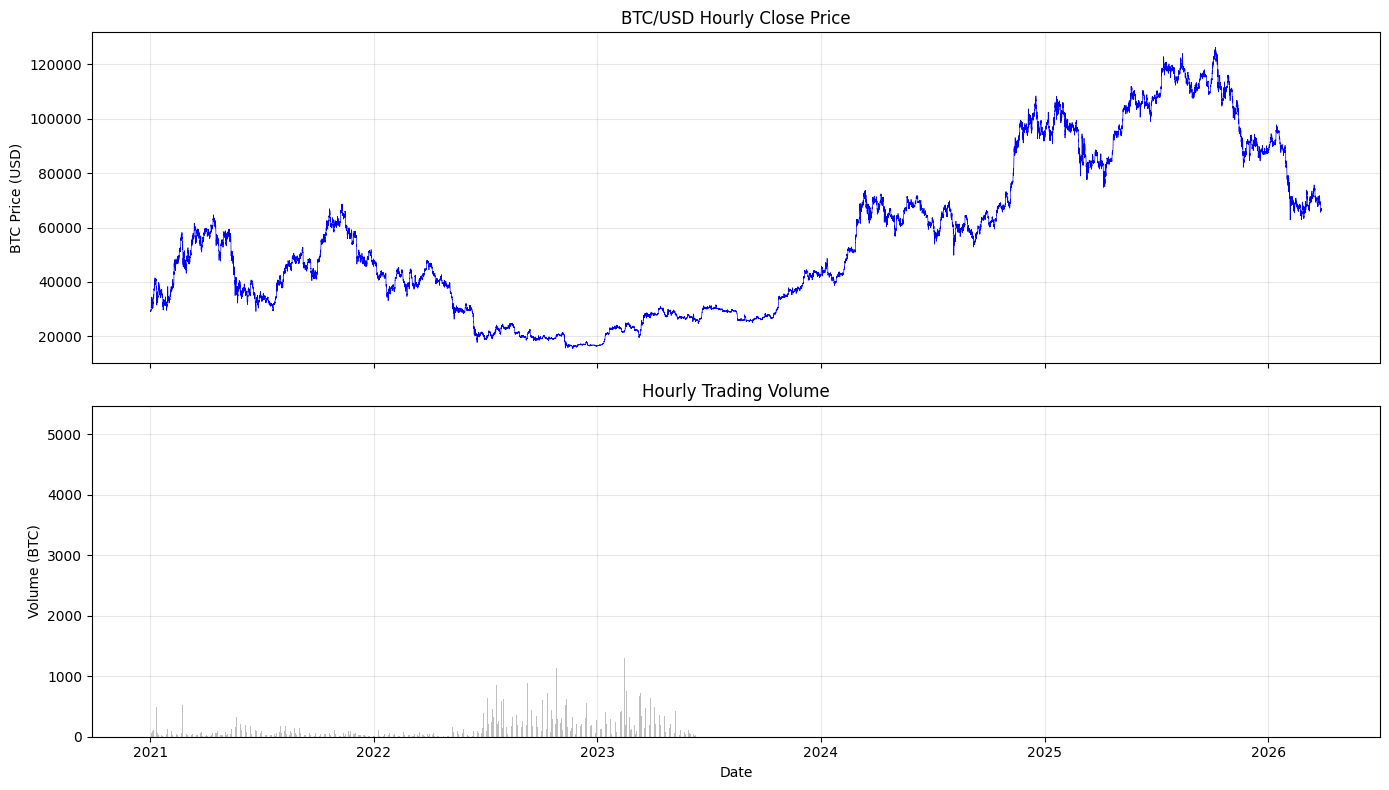


📊 Key observations:
  • Price ranged from $15,632 to $126,117
  • That's a 8x range!
  • BTC is FAR more volatile than SPY (which might move 2x in a decade)


In [14]:
# =============================================================================
# STEP 2.6: Quick visualization of the price history
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price chart
axes[0].plot(df['datetime'], df['close'], linewidth=0.5, color='blue')
axes[0].set_ylabel('BTC Price (USD)')
axes[0].set_title('BTC/USD Hourly Close Price')
axes[0].grid(True, alpha=0.3)

# Volume chart
axes[1].bar(df['datetime'], df['volume'], width=0.02, color='gray', alpha=0.5)
axes[1].set_ylabel('Volume (BTC)')
axes[1].set_xlabel('Date')
axes[1].set_title('Hourly Trading Volume')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key observations to discuss
print("\n📊 Key observations:")
print(f"  • Price ranged from ${df['close'].min():,.0f} to ${df['close'].max():,.0f}")
print(f"  • That's a {df['close'].max()/df['close'].min():.0f}x range!")
print(f"  • BTC is FAR more volatile than SPY (which might move 2x in a decade)")

---
## Section 3: Feature Engineering

### 🎓 Teaching Moment: Features for Volatility Prediction

Your SPY model used these features (from your notebook):
- Log returns
- Absolute returns
- High-low range
- Volume changes
- Historical volatility

We'll use the same features plus a few extras that crypto data provides.

**Why these features?** They all relate to volatility in different ways:

| Feature | Intuition |
|---------|----------|
| Log returns | Recent price movement (volatility tends to cluster) |
| Absolute returns | Magnitude of movement regardless of direction |
| High-low range | Intrabar volatility - wider range = more volatile hour |
| Volume | High volume often accompanies volatility |
| Trade count | Many small trades vs few large trades |
| VWAP deviation | Price diverging from "fair value" may signal stress |

In [15]:
# =============================================================================
# STEP 3.1: Basic return features
# =============================================================================

# 🎓 Teaching Moment: Log Returns vs Simple Returns
#
# Simple return: (P_t - P_{t-1}) / P_{t-1} = P_t/P_{t-1} - 1
# Log return:    log(P_t / P_{t-1}) = log(P_t) - log(P_{t-1})
#
# Log returns have nice properties:
# 1. Additive over time: r_{t to t+2} = r_t + r_{t+1}
# 2. Approximately symmetric: +10% and -10% are similar magnitude
# 3. For small returns, log ≈ simple return
#
# For volatility modeling, log returns are standard.

df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df['abs_return'] = df['log_return'].abs()

print("Log return statistics (hourly):")
print(f"  Mean:   {df['log_return'].mean()*100:.4f}%")
print(f"  Std:    {df['log_return'].std()*100:.4f}%")
print(f"  Min:    {df['log_return'].min()*100:.2f}%")
print(f"  Max:    {df['log_return'].max()*100:.2f}%")
print(f"\nFor comparison, SPY daily returns typically have std ~1%")
print(f"BTC hourly std of {df['log_return'].std()*100:.2f}% shows much higher volatility!")

Log return statistics (hourly):
  Mean:   0.0018%
  Std:    0.6414%
  Min:    -9.93%
  Max:    11.57%

For comparison, SPY daily returns typically have std ~1%
BTC hourly std of 0.64% shows much higher volatility!


In [16]:
# =============================================================================
# STEP 3.2: Range-based volatility features
# =============================================================================

# 🎓 Teaching Moment: Parkinson Volatility
#
# The high-low range within a bar captures intrabar volatility.
# This is related to "Parkinson volatility" - a range-based estimator
# that's more efficient than close-to-close returns because it uses
# more information (the high and low, not just the close).
#
# We normalize by close to make it scale-invariant.

# High-low range as fraction of price
df['hl_range'] = (df['high'] - df['low']) / df['close']

# Log version (for Parkinson-style calculations)
df['hl_log_range'] = np.log(df['high'] / df['low'])

print("High-low range statistics:")
print(f"  Mean range: {df['hl_range'].mean()*100:.3f}% of price per hour")
print(f"  Max range:  {df['hl_range'].max()*100:.2f}% (extreme volatility hour!)")

High-low range statistics:
  Mean range: 0.893% of price per hour
  Max range:  89.21% (extreme volatility hour!)


In [17]:
# =============================================================================
# STEP 3.3: Volume and trade activity features
# =============================================================================

# 🎓 Teaching Moment: Volume as a Volatility Indicator
#
# Volume and volatility often move together:
# - High volatility → more trading activity → high volume
# - News events → both volume and volatility spike
#
# We normalize volume features to handle the long-term growth in BTC trading.

# Volume change (percentage)
df['volume_change'] = df['volume'].pct_change()

# Rolling average volume (24h = 1 day) to normalize
df['volume_ma24'] = df['volume'].rolling(window=24).mean()
df['volume_ratio'] = df['volume'] / df['volume_ma24']

# Trade intensity: trade_count normalized by recent average
df['trade_count_ma24'] = df['trade_count'].rolling(window=24).mean()
df['trade_intensity'] = df['trade_count'] / df['trade_count_ma24']

print("Volume ratio (current / 24h average):")
print(f"  Median: {df['volume_ratio'].median():.2f}x")
print(f"  Max:    {df['volume_ratio'].max():.1f}x (volume spike!)")

Volume ratio (current / 24h average):
  Median: 0.60x
  Max:    23.8x (volume spike!)


In [18]:
# =============================================================================
# STEP 3.4: VWAP-based features
# =============================================================================

# 🎓 Teaching Moment: VWAP (Volume-Weighted Average Price)
#
# VWAP = Σ(price × volume) / Σ(volume) over the bar
#
# It represents the "average" price at which trading occurred.
# If close > VWAP: price ended above the average (bullish pressure)
# If close < VWAP: price ended below the average (bearish pressure)
#
# Large deviations might signal momentum or mean-reversion opportunities.

df['vwap_deviation'] = (df['close'] - df['vwap']) / df['vwap']

print("VWAP deviation statistics:")
print(f"  Mean: {df['vwap_deviation'].mean()*100:.4f}%")
print(f"  Std:  {df['vwap_deviation'].std()*100:.4f}%")

VWAP deviation statistics:
  Mean: inf%
  Std:  nan%


In [19]:
# =============================================================================
# STEP 3.5: Rolling volatility features (key for prediction!)
# =============================================================================

# 🎓 Teaching Moment: Volatility Windows
#
# In your SPY model, you used 5-day rolling volatility.
# For hourly data, we use hour-based windows:
#   - 24 hours = 1 day
#   - 168 hours = 1 week
#
# We'll create multiple windows to capture different timescales.
# The transformer can then learn which timescales matter.

# Standard deviation of returns over different windows
for window in [6, 12, 24, 48, 168]:  # 6h, 12h, 1d, 2d, 1w
    col_name = f'realized_vol_{window}h'
    # Multiply by sqrt(window) to annualize to that window
    df[col_name] = df['log_return'].rolling(window=window).std()

print("Rolling volatility columns added:")
print([c for c in df.columns if 'realized_vol' in c])
print(f"\n24-hour realized volatility mean: {df['realized_vol_24h'].mean()*100:.2f}%")

Rolling volatility columns added:
['realized_vol_6h', 'realized_vol_12h', 'realized_vol_24h', 'realized_vol_48h', 'realized_vol_168h']

24-hour realized volatility mean: 0.55%


In [20]:
# =============================================================================
# STEP 3.6: Time-based features
# =============================================================================

# 🎓 Teaching Moment: Temporal Patterns in Crypto
#
# Unlike stocks (9:30-4:00), crypto trades 24/7.
# But patterns still exist:
#   - Weekday vs weekend behavior
#   - Hour-of-day effects (US market hours overlap)
#
# We encode these as cyclical features using sin/cos.
# This helps the model understand that hour 23 is close to hour 0.

df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday

# Cyclical encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

print("Time features added: hour_sin, hour_cos, dow_sin, dow_cos")

Time features added: hour_sin, hour_cos, dow_sin, dow_cos


---
## Section 4: Bid-Ask Spread Estimation

### 🎓 Teaching Moment: Why Spreads Matter for Trading

**For prediction**: Spreads don't matter. You're predicting volatility.

**For trading**: Spreads are CRITICAL. They're your guaranteed cost.

```
Example:
  BTC price: $100,000
  Spread: 0.1% (bid=$99,950, ask=$100,050)
  
  You buy at ask:  $100,050
  You sell at bid:  $99,950
  Loss just from spread: $100 per BTC (0.1%)
```

If your trading signal averages 0.05% profit per trade but spreads cost 0.1%, you lose money!

### Why Estimate Instead of Use Real Data?

Alpaca only has historical quote (bid/ask) data since October 2025.
We have price bars since April 2020. So we estimate spreads from price characteristics.

In [21]:
# =============================================================================
# STEP 4.1: Spread estimation model
# =============================================================================

# 🎓 Teaching Moment: Spread Estimation Logic
#
# Real spreads depend on:
# 1. Base liquidity (BTC/USD is liquid → small base spread)
# 2. Volatility (high vol → market makers widen spreads for protection)
# 3. Time of day (less liquid hours → wider spreads)
#
# Our simple model:
#   spread = base_spread + volatility_factor × recent_volatility
#
# Typical BTC/USD spreads on major exchanges: 0.01% - 0.20%
# We'll be conservative (assume wider spreads) to avoid over-optimistic backtests.

def estimate_spread(row, base_spread_bps=5, vol_multiplier=10):
    """
    Estimate bid-ask spread in basis points (1 bp = 0.01%).

    Parameters:
    -----------
    base_spread_bps : float
        Minimum spread in basis points (5 bps = 0.05%)
    vol_multiplier : float
        How much to scale spread by hourly volatility
    """
    # Use high-low range as volatility proxy
    hl_range = row['hl_range'] if pd.notna(row['hl_range']) else 0.01

    # Spread widens with volatility
    spread_bps = base_spread_bps + vol_multiplier * hl_range * 100

    # Cap at reasonable bounds (1 bp minimum, 100 bps = 1% maximum)
    spread_bps = np.clip(spread_bps, 1, 100)

    return spread_bps

# Apply spread estimation
df['spread_bps'] = df.apply(estimate_spread, axis=1)
df['spread_pct'] = df['spread_bps'] / 100  # Convert to percentage

# Calculate estimated bid and ask
half_spread = df['spread_pct'] / 100 / 2
df['estimated_bid'] = df['close'] * (1 - half_spread)
df['estimated_ask'] = df['close'] * (1 + half_spread)

print("Spread estimation summary:")
print(f"  Mean spread:   {df['spread_bps'].mean():.1f} bps ({df['spread_pct'].mean():.3f}%)")
print(f"  Median spread: {df['spread_bps'].median():.1f} bps")
print(f"  Max spread:    {df['spread_bps'].max():.1f} bps (during high volatility)")
print(f"\nAt $100k BTC price:")
print(f"  Mean spread cost: ${100000 * df['spread_pct'].mean() / 100:.2f} per trade")

Spread estimation summary:
  Mean spread:   13.8 bps (0.138%)
  Median spread: 11.4 bps
  Max spread:    100.0 bps (during high volatility)

At $100k BTC price:
  Mean spread cost: $138.08 per trade


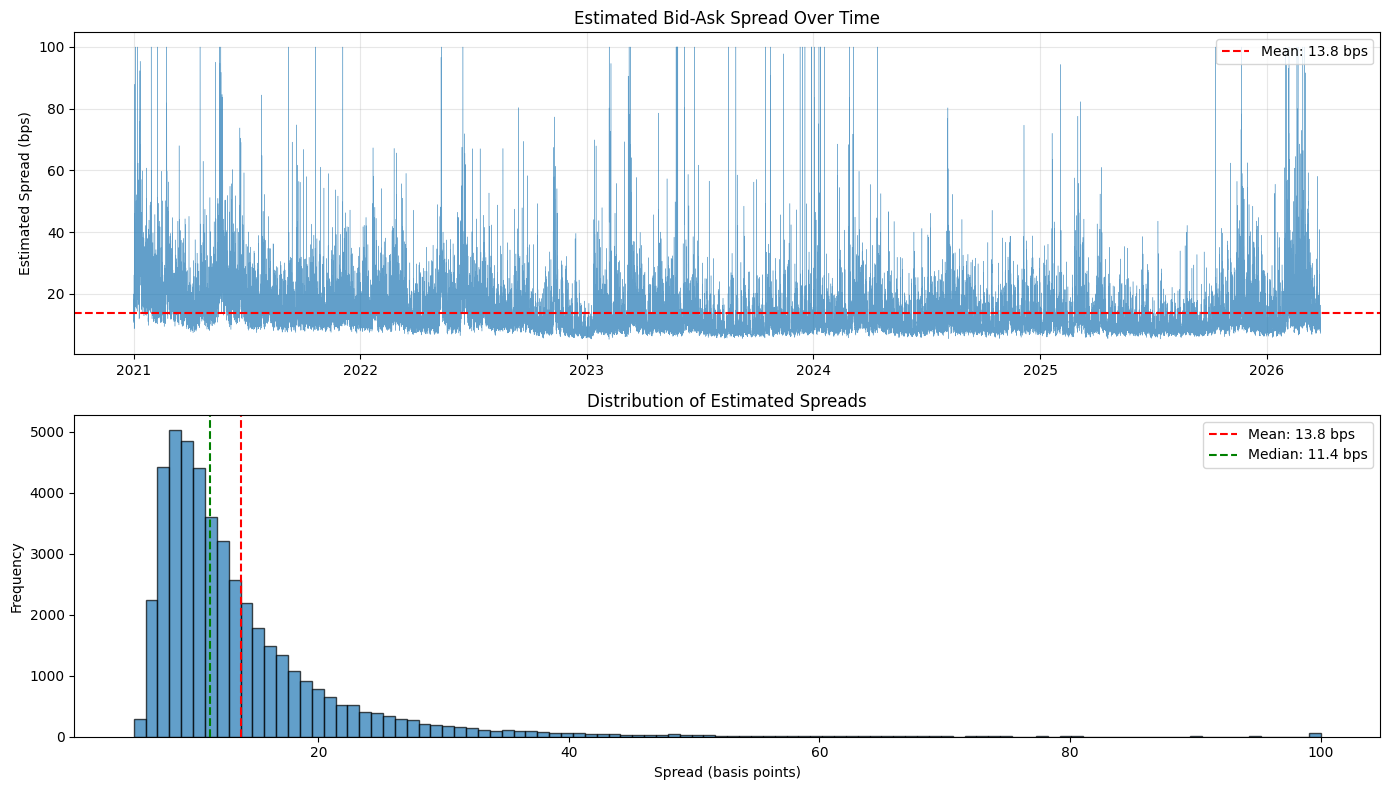


📊 Observation: Spreads spike during volatile periods (look for COVID crash, etc.)


In [22]:
# =============================================================================
# STEP 4.2: Visualize spread estimates
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Spread over time
axes[0].plot(df['datetime'], df['spread_bps'], linewidth=0.3, alpha=0.7)
axes[0].axhline(y=df['spread_bps'].mean(), color='r', linestyle='--', label=f'Mean: {df["spread_bps"].mean():.1f} bps')
axes[0].set_ylabel('Estimated Spread (bps)')
axes[0].set_title('Estimated Bid-Ask Spread Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Spread distribution
axes[1].hist(df['spread_bps'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[1].axvline(x=df['spread_bps'].mean(), color='r', linestyle='--', label=f'Mean: {df["spread_bps"].mean():.1f} bps')
axes[1].axvline(x=df['spread_bps'].median(), color='g', linestyle='--', label=f'Median: {df["spread_bps"].median():.1f} bps')
axes[1].set_xlabel('Spread (basis points)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Estimated Spreads')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n📊 Observation: Spreads spike during volatile periods (look for COVID crash, etc.)")

---
## Section 5: Target Variable (What We Predict)

### 🎓 Teaching Moment: Forward Realized Volatility

Your SPY model predicted **5-day forward realized volatility**:
- Look at the next 5 days of returns
- Calculate their standard deviation
- That's your target

For hourly BTC data, we'll predict **24-hour forward volatility** (equivalent to 1 day).

**Why "realized" volatility?**
- It's computable ex-post (after the fact)
- It gives us a clear target to train against
- It's what trading strategies often need to estimate

In [23]:
# =============================================================================
# STEP 5.1: Compute forward realized volatility
# =============================================================================

# 🎓 Teaching Moment: The Shift Trick
#
# To compute FORWARD volatility at time t, we need returns from t+1 to t+24.
# We use .shift(-n) to "look into the future" from each row's perspective.
#
# IMPORTANT: This creates "future" information in the target column.
# That's fine for training (we're predicting it), but we must ensure
# the model features don't contain future information!

FORWARD_WINDOW = 24  # Predict 24 hours ahead

def compute_forward_volatility(series, window):
    """
    Compute forward-looking realized volatility.

    For each time t, this computes std(returns[t+1 : t+window+1])
    """
    # Shift returns backward (so we're looking at future returns from current perspective)
    future_returns = series.shift(-1)  # Start from next period

    # Rolling std of the shifted series
    # We use .shift(-window+1) to align the window correctly
    forward_vol = future_returns.rolling(window=window).std().shift(-window+1)

    return forward_vol

df['target_vol_24h'] = compute_forward_volatility(df['log_return'], FORWARD_WINDOW)

print(f"Target: {FORWARD_WINDOW}-hour forward realized volatility")
print(f"\nTarget statistics:")
print(f"  Mean:   {df['target_vol_24h'].mean()*100:.3f}%")
print(f"  Std:    {df['target_vol_24h'].std()*100:.3f}%")
print(f"  Min:    {df['target_vol_24h'].min()*100:.3f}%")
print(f"  Max:    {df['target_vol_24h'].max()*100:.3f}%")
print(f"\nNaN count: {df['target_vol_24h'].isna().sum()} (expected at end of series)")

Target: 24-hour forward realized volatility

Target statistics:
  Mean:   0.548%
  Std:    0.335%
  Min:    0.046%
  Max:    3.528%

NaN count: 24 (expected at end of series)


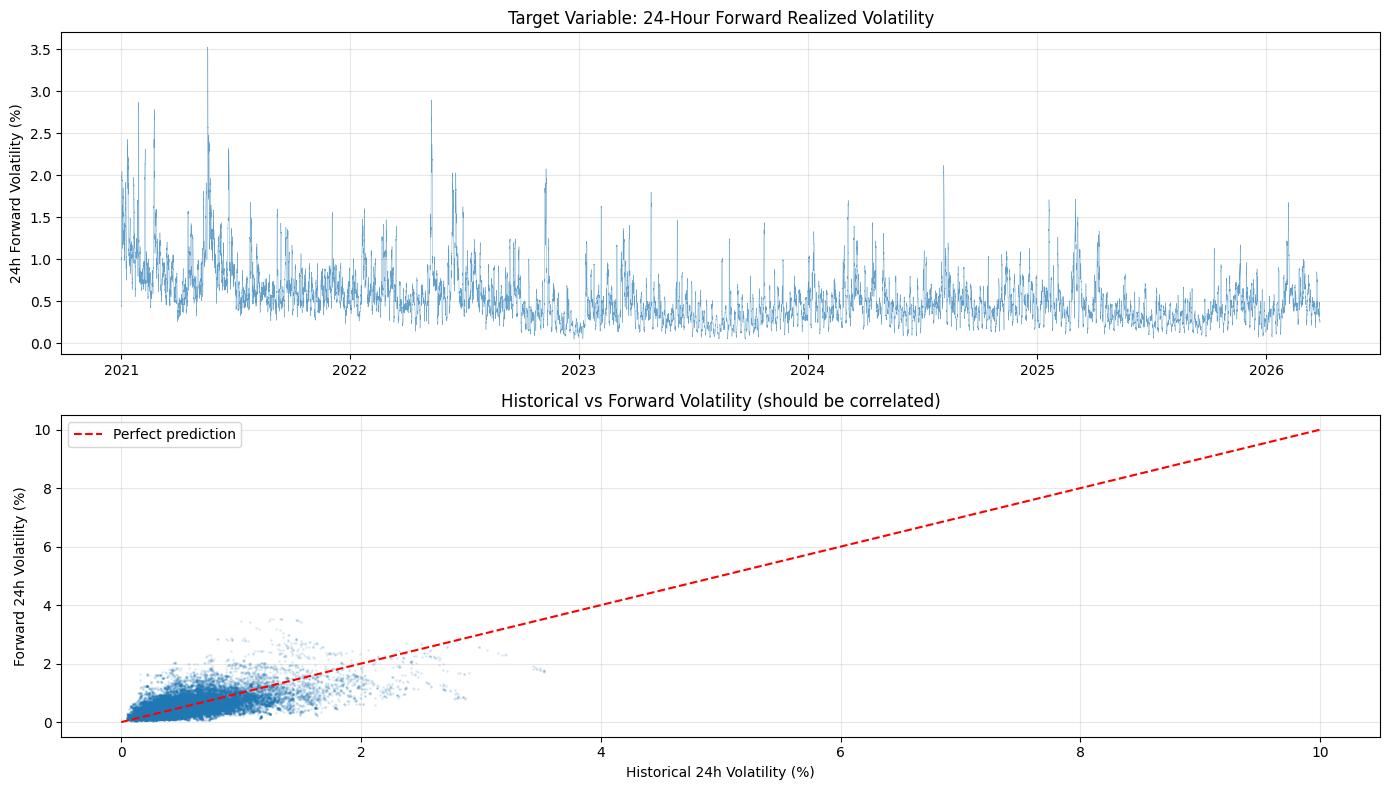


📊 Correlation between historical and forward volatility: 0.598
   This shows volatility clustering - high vol tends to be followed by high vol.
   But correlation < 1 means there's room for a model to add value!


In [24]:
# =============================================================================
# STEP 5.2: Visualize target variable
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Target over time
axes[0].plot(df['datetime'], df['target_vol_24h'] * 100, linewidth=0.3, alpha=0.7)
axes[0].set_ylabel('24h Forward Volatility (%)')
axes[0].set_title('Target Variable: 24-Hour Forward Realized Volatility')
axes[0].grid(True, alpha=0.3)

# Compare with historical volatility (should be correlated but not identical)
axes[1].scatter(df['realized_vol_24h'] * 100, df['target_vol_24h'] * 100,
                alpha=0.1, s=1)
axes[1].plot([0, 10], [0, 10], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Historical 24h Volatility (%)')
axes[1].set_ylabel('Forward 24h Volatility (%)')
axes[1].set_title('Historical vs Forward Volatility (should be correlated)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation
corr = df['realized_vol_24h'].corr(df['target_vol_24h'])
print(f"\n📊 Correlation between historical and forward volatility: {corr:.3f}")
print("   This shows volatility clustering - high vol tends to be followed by high vol.")
print("   But correlation < 1 means there's room for a model to add value!")

---
## Section 6: Data Splits (Chronological!)

### 🎓 Teaching Moment: Why Chronological Splits?

**For image classification**: Random 80/20 split is fine.

**For time series**: **NEVER** split randomly!

Why? If training data includes Dec 2023 and test data includes Nov 2023,
your model could "learn" patterns from the future. This is called **data leakage**.

```
WRONG (random split):
  Train: [Jan, Mar, May, Jul, Sep, Nov, ...]
  Test:  [Feb, Apr, Jun, Aug, Oct, Dec, ...]
  → Model sees future data during training!

RIGHT (chronological split):
  Train: [Jan - Sep]   (70%)
  Val:   [Oct - Nov]   (15%)
  Test:  [Dec]         (15%)
  → Model only trained on past data
```

In [25]:
# =============================================================================
# STEP 6.1: Define feature columns
# =============================================================================

# 🎓 Teaching Moment: Feature Selection
#
# We carefully select only features that are KNOWN at prediction time.
# The target (forward volatility) and spread estimates for trading are separate.

# Features for the transformer model
FEATURE_COLS = [
    # Return-based
    'log_return',
    'abs_return',

    # Range-based
    'hl_range',
    'hl_log_range',

    # Volume-based
    'volume_ratio',
    'trade_intensity',

    # VWAP-based
    'vwap_deviation',

    # Historical volatility at different scales
    'realized_vol_6h',
    'realized_vol_12h',
    'realized_vol_24h',
    'realized_vol_48h',
    'realized_vol_168h',

    # Time features
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
]

# Target column
TARGET_COL = 'target_vol_24h'

# Columns needed for trading evaluation (kept but not used as features)
TRADING_COLS = [
    'datetime',
    'open', 'high', 'low', 'close',
    'volume',
    'spread_bps', 'spread_pct',
    'estimated_bid', 'estimated_ask',
]

print(f"Number of features: {len(FEATURE_COLS)}")
print(f"\nFeature columns:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {col}")

Number of features: 16

Feature columns:
   1. log_return
   2. abs_return
   3. hl_range
   4. hl_log_range
   5. volume_ratio
   6. trade_intensity
   7. vwap_deviation
   8. realized_vol_6h
   9. realized_vol_12h
  10. realized_vol_24h
  11. realized_vol_48h
  12. realized_vol_168h
  13. hour_sin
  14. hour_cos
  15. dow_sin
  16. dow_cos


In [26]:
# =============================================================================
# STEP 6.2: Clean data (drop NaNs)
# =============================================================================

# Check for NaNs
print("NaN counts before cleaning:")
nan_counts = df[FEATURE_COLS + [TARGET_COL]].isna().sum()
print(nan_counts[nan_counts > 0])

# Drop rows with NaN in features or target
df_clean = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()

print(f"\nRows before cleaning: {len(df):,}")
print(f"Rows after cleaning:  {len(df_clean):,}")
print(f"Rows dropped:         {len(df) - len(df_clean):,}")
print(f"\nDate range after cleaning:")
print(f"  {df_clean['datetime'].min()} to {df_clean['datetime'].max()}")

NaN counts before cleaning:
log_return             1
abs_return             1
volume_ratio          23
trade_intensity       23
realized_vol_6h        6
realized_vol_12h      12
realized_vol_24h      24
realized_vol_48h      48
realized_vol_168h    168
target_vol_24h        24
dtype: int64

Rows before cleaning: 45,893
Rows after cleaning:  45,701
Rows dropped:         192

Date range after cleaning:
  2021-01-08 06:00:00 to 2026-03-28 00:00:00


In [27]:
# =============================================================================
# STEP 6.3: Chronological split
# =============================================================================

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

n = len(df_clean)
train_end = int(n * TRAIN_FRAC)
val_end = int(n * (TRAIN_FRAC + VAL_FRAC))

train_df = df_clean.iloc[:train_end].copy()
val_df = df_clean.iloc[train_end:val_end].copy()
test_df = df_clean.iloc[val_end:].copy()

print("=" * 60)
print("CHRONOLOGICAL DATA SPLITS")
print("=" * 60)
print(f"\nTraining set:   {len(train_df):,} samples ({len(train_df)/24:,.0f} days)")
print(f"  Date range:   {train_df['datetime'].min().date()} to {train_df['datetime'].max().date()}")
print(f"\nValidation set: {len(val_df):,} samples ({len(val_df)/24:,.0f} days)")
print(f"  Date range:   {val_df['datetime'].min().date()} to {val_df['datetime'].max().date()}")
print(f"\nTest set:       {len(test_df):,} samples ({len(test_df)/24:,.0f} days)")
print(f"  Date range:   {test_df['datetime'].min().date()} to {test_df['datetime'].max().date()}")

CHRONOLOGICAL DATA SPLITS

Training set:   31,990 samples (1,333 days)
  Date range:   2021-01-08 to 2024-09-02

Validation set: 6,855 samples (286 days)
  Date range:   2024-09-02 to 2025-06-15

Test set:       6,856 samples (286 days)
  Date range:   2025-06-15 to 2026-03-28


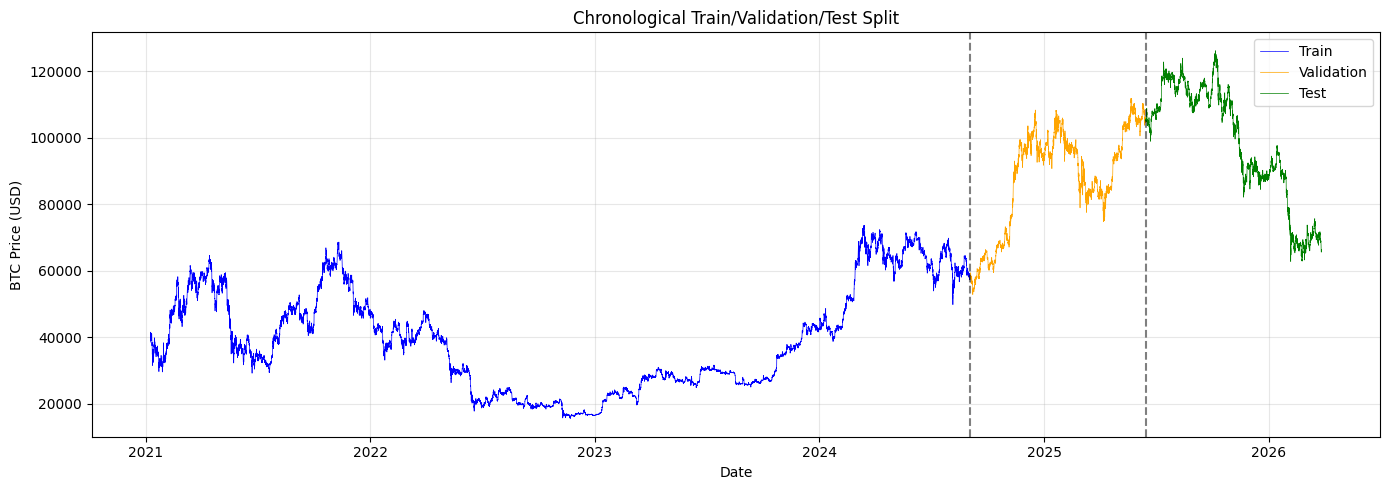


📊 Note: Each split covers a different market regime!
   This tests the model's ability to generalize to new conditions.


In [28]:
# =============================================================================
# STEP 6.4: Visualize the splits
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_df['datetime'], train_df['close'], label='Train', color='blue', linewidth=0.5)
ax.plot(val_df['datetime'], val_df['close'], label='Validation', color='orange', linewidth=0.5)
ax.plot(test_df['datetime'], test_df['close'], label='Test', color='green', linewidth=0.5)

# Add vertical lines at split points
ax.axvline(x=train_df['datetime'].max(), color='black', linestyle='--', alpha=0.5)
ax.axvline(x=val_df['datetime'].max(), color='black', linestyle='--', alpha=0.5)

ax.set_ylabel('BTC Price (USD)')
ax.set_xlabel('Date')
ax.set_title('Chronological Train/Validation/Test Split')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Note: Each split covers a different market regime!")
print("   This tests the model's ability to generalize to new conditions.")

---
## Section 7: Feature Normalization

### 🎓 Teaching Moment: Why Normalize?

Neural networks work best when inputs are roughly on the same scale.

```
Without normalization:
  - volume_ratio: 0 to 50
  - realized_vol: 0 to 0.05
  → Network struggles to learn weights for tiny values

With normalization:
  - volume_ratio: -2 to +3 (standard deviations from mean)
  - realized_vol: -2 to +3
  → All features contribute equally
```

**Critical**: Fit the normalizer on TRAINING data only!
Then apply it to validation and test. Otherwise you leak information.

In [29]:
# =============================================================================
# STEP 7.1: Compute normalization statistics from training data
# =============================================================================

# 🎓 Teaching Moment: StandardScaler Logic
#
# For each feature, we compute:
#   mean = average value in training set
#   std  = standard deviation in training set
#
# Then transform: x_normalized = (x - mean) / std
#
# This gives features with mean≈0 and std≈1.

# Calculate statistics from training data only
feature_stats = {}
for col in FEATURE_COLS:
    feature_stats[col] = {
        'mean': train_df[col].mean(),
        'std': train_df[col].std()
    }

# Also for target
target_stats = {
    'mean': train_df[TARGET_COL].mean(),
    'std': train_df[TARGET_COL].std()
}

print("Feature normalization statistics (from training data):")
print(f"{'Feature':<25} {'Mean':>12} {'Std':>12}")
print("-" * 50)
for col in FEATURE_COLS[:5]:  # Show first 5
    print(f"{col:<25} {feature_stats[col]['mean']:>12.6f} {feature_stats[col]['std']:>12.6f}")
print("...")
print(f"\nTarget ({TARGET_COL}):")
print(f"  Mean: {target_stats['mean']:.6f}")
print(f"  Std:  {target_stats['std']:.6f}")

Feature normalization statistics (from training data):
Feature                           Mean          Std
--------------------------------------------------
log_return                    0.000014     0.006868
abs_return                    0.004250     0.005395
hl_range                      0.009418     0.012043
hl_log_range                  0.009474     0.016246
volume_ratio                  1.033958     1.497791
...

Target (target_vol_24h):
  Mean: 0.005861
  Std:  0.003573


In [30]:
# =============================================================================
# STEP 7.2: Apply normalization to all splits
# =============================================================================

def normalize_features(df, stats, columns):
    """Normalize features using pre-computed statistics."""
    df_norm = df.copy()
    for col in columns:
        mean = stats[col]['mean']
        std = stats[col]['std']
        # Avoid division by zero
        if std > 0:
            df_norm[col] = (df[col] - mean) / std
        else:
            df_norm[col] = 0
    return df_norm

# Normalize features in each split
train_df = normalize_features(train_df, feature_stats, FEATURE_COLS)
val_df = normalize_features(val_df, feature_stats, FEATURE_COLS)
test_df = normalize_features(test_df, feature_stats, FEATURE_COLS)

# Note: We keep target in original scale for interpretability
# (or normalize if needed for training stability)

print("✓ Features normalized using training statistics")
print("\nNormalized feature statistics (training set, should be ~0 mean, ~1 std):")
print(train_df[FEATURE_COLS].describe().loc[['mean', 'std']].T.head())

✓ Features normalized using training statistics

Normalized feature statistics (training set, should be ~0 mean, ~1 std):
                      mean  std
log_return    1.154993e-17  1.0
abs_return    9.239943e-17  1.0
hl_range      2.843059e-17  1.0
hl_log_range -4.264589e-17  1.0
volume_ratio -1.332684e-17  1.0


---
## Section 8: Save Everything

We save:
1. **Processed DataFrames** - for model training
2. **Normalization statistics** - to apply same scaling to new data
3. **Column definitions** - to reconstruct features later

In [31]:
# =============================================================================
# STEP 8.1: Save processed data to CSV
# =============================================================================

# Save each split
train_df.to_csv('btc_train.csv', index=False)
val_df.to_csv('btc_val.csv', index=False)
test_df.to_csv('btc_test.csv', index=False)

print("✓ Saved CSV files:")
print(f"  btc_train.csv: {len(train_df):,} rows")
print(f"  btc_val.csv:   {len(val_df):,} rows")
print(f"  btc_test.csv:  {len(test_df):,} rows")

✓ Saved CSV files:
  btc_train.csv: 31,990 rows
  btc_val.csv:   6,855 rows
  btc_test.csv:  6,856 rows


In [32]:
# =============================================================================
# STEP 8.2: Save metadata (normalization stats, column names)
# =============================================================================

import json

metadata = {
    'feature_columns': FEATURE_COLS,
    'target_column': TARGET_COL,
    'trading_columns': TRADING_COLS,
    'feature_stats': feature_stats,
    'target_stats': target_stats,
    'forward_window': FORWARD_WINDOW,
    'data_range': {
        'start': str(START_DATE.date()),
        'end': str(END_DATE.date())
    },
    'split_sizes': {
        'train': len(train_df),
        'val': len(val_df),
        'test': len(test_df)
    }
}

with open('btc_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✓ Saved btc_metadata.json")
print("\nThis file contains everything needed to:")
print("  - Reconstruct features for new data")
print("  - Apply the same normalization")
print("  - Know which columns are features vs trading info")

✓ Saved btc_metadata.json

This file contains everything needed to:
  - Reconstruct features for new data
  - Apply the same normalization
  - Know which columns are features vs trading info


In [33]:
# =============================================================================
# STEP 8.3: Optional - Save to Google Drive for persistence
# =============================================================================

# Uncomment these lines to save to Google Drive
# (Files in Colab session storage are lost when the runtime disconnects)

from google.colab import drive
drive.mount('/content/drive')

# # Create a folder for this project
import os
save_dir = '/content/drive/MyDrive/btc_volatility_project'
os.makedirs(save_dir, exist_ok=True)

# # Copy files
train_df.to_csv(f'{save_dir}/btc_train.csv', index=False)
val_df.to_csv(f'{save_dir}/btc_val.csv', index=False)
test_df.to_csv(f'{save_dir}/btc_test.csv', index=False)
with open(f'{save_dir}/btc_metadata.json', 'w') as f:
     json.dump(metadata, f, indent=2)

# print(f"✓ Files saved to Google Drive: {save_dir}")

print("💡 Tip: Uncomment the code above to persist files to Google Drive")

Mounted at /content/drive
💡 Tip: Uncomment the code above to persist files to Google Drive


---
## Section 9: Summary and Next Steps

### What We Built

| Component | Description |
|-----------|-------------|
| **Data Pipeline** | Fetch ~39,000 hourly BTC bars from Alpaca |
| **Features** | 17 features including returns, volatility, volume, time |
| **Target** | 24-hour forward realized volatility |
| **Spreads** | Estimated bid-ask spreads for trading evaluation |
| **Splits** | Chronological 70/15/15 train/val/test |
| **Normalization** | Fitted on training data only |

In [34]:
# =============================================================================
# Final summary statistics
# =============================================================================

print("=" * 60)
print("BTC VOLATILITY DATA PIPELINE - SUMMARY")
print("=" * 60)
print(f"\n📊 Data:")
print(f"   Total samples: {len(train_df) + len(val_df) + len(test_df):,}")
print(f"   Date range: {START_DATE.date()} to {END_DATE.date()}")
print(f"   Timeframe: Hourly bars")

print(f"\n🔧 Features:")
print(f"   Count: {len(FEATURE_COLS)}")
print(f"   Categories: returns, volatility, volume, time")

print(f"\n🎯 Target:")
print(f"   24-hour forward realized volatility")
print(f"   Mean: {target_stats['mean']*100:.3f}%")
print(f"   Std:  {target_stats['std']*100:.3f}%")

print(f"\n💰 Trading Preparation:")
print(f"   Spread estimation: ✓")
print(f"   Mean spread: {df_clean['spread_bps'].mean():.1f} bps")
print(f"   Bid/ask prices: ✓")

print(f"\n📁 Files Saved:")
print(f"   btc_train.csv ({len(train_df):,} rows)")
print(f"   btc_val.csv ({len(val_df):,} rows)")
print(f"   btc_test.csv ({len(test_df):,} rows)")
print(f"   btc_metadata.json")

print(f"\n🚀 Next Steps:")
print(f"   1. Build transformer model (Part 2 notebook)")
print(f"   2. Train and evaluate predictions")
print(f"   3. Build trading strategy (Part 3 notebook)")
print(f"   4. Wrap as MCP agent (Week 4 capstone)")

BTC VOLATILITY DATA PIPELINE - SUMMARY

📊 Data:
   Total samples: 45,701
   Date range: 2021-01-01 to 2026-03-29
   Timeframe: Hourly bars

🔧 Features:
   Count: 16
   Categories: returns, volatility, volume, time

🎯 Target:
   24-hour forward realized volatility
   Mean: 0.586%
   Std:  0.357%

💰 Trading Preparation:
   Spread estimation: ✓
   Mean spread: 13.8 bps
   Bid/ask prices: ✓

📁 Files Saved:
   btc_train.csv (31,990 rows)
   btc_val.csv (6,855 rows)
   btc_test.csv (6,856 rows)
   btc_metadata.json

🚀 Next Steps:
   1. Build transformer model (Part 2 notebook)
   2. Train and evaluate predictions
   3. Build trading strategy (Part 3 notebook)
   4. Wrap as MCP agent (Week 4 capstone)


---
## 🎓 Key Learnings from This Notebook

1. **API Key Security**: Use Colab Secrets, never hardcode keys

2. **Stock vs Crypto APIs**: Different clients, different requirements

3. **Feature Engineering**:
   - Return-based features capture recent momentum
   - Range-based features capture intrabar volatility
   - Volume features capture market activity
   - Multiple volatility windows capture different timescales

4. **Spread Estimation**: Critical for realistic trading evaluation

5. **Chronological Splits**: Never randomly split time series!

6. **Normalization**: Fit on training data only, then apply to all splits

---

**Questions to think about before Part 2:**
- How will the transformer's attention mechanism help with volatility prediction?
- What sequence length should we use? (How many hours of history?)
- Should we predict normalized or raw volatility?